Saved GIFs:
 - c:\Users\knut1\Documents\Computer_Vision_Exercises\Chapter_3_Image_Processing\outputs_ex3_16\houses_resample_compare.gif
 - c:\Users\knut1\Documents\Computer_Vision_Exercises\Chapter_3_Image_Processing\outputs_ex3_16\chirp_resample_compare.gif


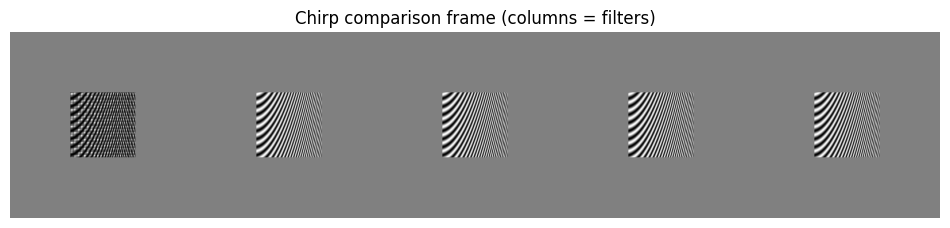

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import imageio.v2 as imageio

# -----------------------------
# Paths
# -----------------------------
img_path = os.path.join("..", "Files", "Random_Images", "houses_3.jpg")

# -----------------------------
# Utilities
# -----------------------------
def clip01(x): return np.clip(x, 0.0, 1.0)

def load_rgb01(path):
    im = Image.open(path).convert("RGB")
    return np.asarray(im).astype(np.float32) / 255.0

def rgb01_to_u8(x):
    return (clip01(x) * 255.0 + 0.5).astype(np.uint8)

# Padding index mapping (Ex 3.9 style)
def pmod(x, m):
    return ((x % m) + m) % m

def reflect_index(i, M):
    if M <= 1: return 0
    period = 2*M - 2
    r = pmod(i, period)
    return r if r <= M-1 else (2*M - 2 - r)

def symmetric_index(i, M):
    if M <= 1: return 0
    period = 2*M
    r = pmod(i, period)
    return r if r <= M-1 else (2*M - 1 - r)

def map_indices(idx, length, mode):
    idx = idx.astype(np.int64)
    if mode == "clamp":
        return np.clip(idx, 0, length-1)
    if mode == "wrap":
        return pmod(idx, length)
    if mode == "reflect":
        return np.array([reflect_index(i, length) for i in idx], dtype=np.int64)
    if mode == "symmetric":
        return np.array([symmetric_index(i, length) for i in idx], dtype=np.int64)
    raise ValueError("mode must be clamp/wrap/reflect/symmetric")

# -----------------------------
# Kernels
# -----------------------------
def sinc(x):
    x = np.asarray(x, dtype=np.float32)
    y = np.ones_like(x)
    nz = np.abs(x) > 1e-8
    y[nz] = np.sin(np.pi*x[nz]) / (np.pi*x[nz])
    return y

def kernel_nearest(x):
    return (np.abs(x) < 0.5).astype(np.float32)

def kernel_tent(x):
    ax = np.abs(x)
    return np.maximum(0.0, 1.0 - ax).astype(np.float32)

def kernel_cubic(x, a=-0.5):
    ax = np.abs(x).astype(np.float32)
    out = np.zeros_like(ax)
    m1 = ax < 1.0
    m2 = (ax >= 1.0) & (ax < 2.0)
    out[m1] = 1.0 - (a + 3.0)*ax[m1]**2 + (a + 2.0)*ax[m1]**3
    out[m2] = a*(ax[m2] - 1.0)*(ax[m2] - 2.0)**2
    return out

def kernel_windowed_sinc_rcos(x, radius=4.0):
    ax = np.abs(x).astype(np.float32)
    w = np.zeros_like(ax)
    m = ax <= radius
    w[m] = 0.5*(1.0 + np.cos(np.pi*ax[m]/radius))
    return sinc(x) * w

KERNELS = {
    "nearest": (kernel_nearest, 0.5),
    "tent": (kernel_tent, 1.0),
    "cubic_a_-0.5": (lambda x: kernel_cubic(x, a=-0.5), 2.0),
    "cubic_a_-1.0": (lambda x: kernel_cubic(x, a=-1.0), 2.0),
    "win_sinc_rcos_r4": (lambda x: kernel_windowed_sinc_rcos(x, radius=4.0), 4.0),
}

# -----------------------------
# Resampling core
# -----------------------------
def precompute_1d_weights(in_len, out_len, scale, kernel_fn, support, padding="reflect"):
    u = np.arange(out_len, dtype=np.float32)
    x = (u + 0.5)/scale - 0.5  # pixel-center mapping

    if scale < 1.0:
        support_s = support / scale
        left = np.floor(x - support_s).astype(np.int64)
        right = np.ceil(x + support_s).astype(np.int64)
    else:
        support_s = support
        left = np.floor(x - support_s).astype(np.int64)
        right = np.ceil(x + support_s).astype(np.int64)

    max_taps = int(np.max(right - left + 1))
    idx = left[:, None] + np.arange(max_taps)[None, :]

    dist = x[:, None] - idx.astype(np.float32)

    if scale < 1.0:
        w = (1.0/scale) * kernel_fn(dist/scale)
    else:
        w = kernel_fn(dist)

    mask = (idx >= left[:, None]) & (idx <= right[:, None])
    w *= mask.astype(np.float32)

    idx_mapped = map_indices(idx.ravel(), in_len, padding).reshape(idx.shape)

    wsum = np.sum(w, axis=1, keepdims=True) + 1e-12
    w = w / wsum
    return idx_mapped, w

def resample_separable(img, out_h, out_w, kernel_name="cubic_a_-0.5", padding="reflect"):
    kernel_fn, support = KERNELS[kernel_name]
    H, W, C = img.shape
    scale_x = out_w / W
    scale_y = out_h / H

    idx_x, w_x = precompute_1d_weights(W, out_w, scale_x, kernel_fn, support, padding=padding)
    idx_y, w_y = precompute_1d_weights(H, out_h, scale_y, kernel_fn, support, padding=padding)

    tmp = np.zeros((H, out_w, C), dtype=np.float32)
    for y in range(H):
        row = img[y, :, :]           # (W,C)
        samples = row[idx_x, :]      # (out_w,taps,C)
        tmp[y, :, :] = np.einsum("wtc,wt->wc", samples, w_x)

    out = np.zeros((out_h, out_w, C), dtype=np.float32)
    for x in range(out_w):
        col = tmp[:, x, :]           # (H,C)
        samples = col[idx_y, :]      # (out_h,taps,C)
        out[:, x, :] = np.einsum("htc,ht->hc", samples, w_y)

    return clip01(out)

# -----------------------------
# Synthetic chirp image
# -----------------------------
def make_chirp(h=512, w=512):
    y = np.linspace(0, 1, h, dtype=np.float32)[:, None]
    x = np.linspace(0, 1, w, dtype=np.float32)[None, :]
    f0, k = 2.0, 40.0
    phase = 2*np.pi*(f0*x + 0.5*k*x*x)
    img = 0.5 + 0.5*np.sin(phase + 2*np.pi*8.0*y)
    rgb = np.dstack([img, img, img]).astype(np.float32)
    return rgb

# -----------------------------
# Canvas helper: paste variable-size tile into fixed-size tile
# -----------------------------
def paste_center(tile_u8, tile_h, tile_w, bg=128):
    """
    tile_u8: HxWx3 uint8, variable size
    returns: tile_h x tile_w x 3 uint8
    """
    canvas = np.full((tile_h, tile_w, 3), bg, dtype=np.uint8)
    h, w = tile_u8.shape[:2]
    # if too big, center-crop
    if h > tile_h:
        y0 = (h - tile_h)//2
        tile_u8 = tile_u8[y0:y0+tile_h, :, :]
        h = tile_h
    if w > tile_w:
        x0 = (w - tile_w)//2
        tile_u8 = tile_u8[:, x0:x0+tile_w, :]
        w = tile_w
    # center paste
    y0 = (tile_h - h)//2
    x0 = (tile_w - w)//2
    canvas[y0:y0+h, x0:x0+w, :] = tile_u8
    return canvas

# -----------------------------
# Animation: constant frame size
# -----------------------------
def make_resize_animation_fixed_canvas(
    img, kernel_names, scales,
    base_out_h=280, padding="reflect",
    save_path=None, fps=20
):
    # Make a base version at manageable size
    H, W, _ = img.shape
    base_scale = base_out_h / H
    base = resample_separable(img, int(H*base_scale), int(W*base_scale),
                              kernel_name="cubic_a_-0.5", padding=padding)
    Hb, Wb, _ = base.shape

    # Determine max tile size across all scales (so every frame can use same canvas)
    max_h = max(8, int(Hb * np.max(scales)))
    max_w = max(8, int(Wb * np.max(scales)))

    frames = []
    for s in scales:
        out_h = max(8, int(Hb * s))
        out_w = max(8, int(Wb * s))

        tiles = []
        for kname in kernel_names:
            r = resample_separable(base, out_h, out_w, kernel_name=kname, padding=padding)
            tile = rgb01_to_u8(r)
            tiles.append(paste_center(tile, max_h, max_w, bg=128))

        frame = np.concatenate(tiles, axis=1)  # same height always
        frames.append(frame)

    if save_path is not None:
        imageio.mimsave(save_path, frames, fps=fps)

    return frames

# -----------------------------
# Run
# -----------------------------
houses = load_rgb01(img_path)
chirp = make_chirp(512, 512)

kernel_list = ["nearest", "tent", "cubic_a_-0.5", "cubic_a_-1.0", "win_sinc_rcos_r4"]
scales = np.concatenate([np.linspace(0.35, 2.2, 45), np.linspace(2.2, 0.35, 45)]).astype(np.float32)

out_dir = "outputs_ex3_16"
os.makedirs(out_dir, exist_ok=True)
gif_houses = os.path.join(out_dir, "houses_resample_compare.gif")
gif_chirp  = os.path.join(out_dir, "chirp_resample_compare.gif")

frames_houses = make_resize_animation_fixed_canvas(
    houses, kernel_list, scales, base_out_h=280, padding="reflect", save_path=gif_houses, fps=20
)
frames_chirp = make_resize_animation_fixed_canvas(
    chirp, kernel_list, scales, base_out_h=280, padding="reflect", save_path=gif_chirp, fps=20
)

print("Saved GIFs:")
print(" -", os.path.abspath(gif_houses))
print(" -", os.path.abspath(gif_chirp))

# Preview a frame
plt.figure(figsize=(12,5))
plt.imshow(frames_chirp[10])
plt.title("Chirp comparison frame (columns = filters)")
plt.axis("off")
plt.show()
